# Modern Pipeline - Complete Workflow

This notebook demonstrates the **modern approach** to data processing using the complete toolkit.

**One command instead of manual processing for each dataset!**

## Setup

In [21]:
from pathlib import Path
import sys

# Setup paths
REPO_ROOT = Path.cwd().resolve().parent
SRC_PATH = REPO_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

print(f"✅ Repository root: {REPO_ROOT}")

✅ Repository root: C:\Users\Anton\economics-of-the-welfare-state


## 🚀 Part 1: Modern Pipeline (ONE COMMAND!)

Process all 6 datasets with a single function call:

In [22]:
from clean import process_all_datasets, merge_all_datasets

# Process ALL datasets with one command!
results = process_all_datasets(
    repo_root=REPO_ROOT,
    year_min=1980,
    year_max=2023,
    validate=True,
    save_outputs=True
)

print(f"\n✅ Processed {len(results)} datasets!")
for name, df in results.items():
    if df is not None:
        print(f"   {name}: {len(df):,} observations")

🔄 Processing all datasets...

📊 Processing CPDS...
⚠️  CPDS: Missing data detected in: {'sstran': 44, 'deficit': 59, 'debt': 82}
✅ CPDS validation passed: 1310 rows, 32 countries
✅ CPDS: 1310 rows

👥 Processing Population...
✅ Population validation passed: 1408 rows, 32 countries
✅ Population: 1408 rows

💰 Processing GDP per capita...
⚠️  GDP per capita: Missing data detected in: {'ln_gdppc': 116}
✅ GDP per capita validation passed: 1408 rows, 32 countries
✅ GDP per capita: 1408 rows

📈 Processing Inflation CPI...
⚠️  Calamine read failed: No module named 'calamine'
⚠️  Inflation CPI: Missing data detected in: {'inflation_cpi': 97}
✅ Inflation CPI validation passed: 1408 rows, 32 countries
✅ Inflation CPI: 1408 rows

👶👴 Processing Dependency Ratio...
✅ Dependency Ratio validation passed: 1088 rows, 32 countries
✅ Dependency Ratio: 1088 rows

🌍 Processing KOF Globalization Index...
✅ KOF Globalization Index validation passed: 1340 rows, 32 countries
✅ KOF Index: 1340 rows

✅ Completed: 

In [23]:
# Merge into master dataset
master = merge_all_datasets(results, how='outer')

print(f"\n📊 Master Dataset:")
print(f"   {len(master):,} observations")
print(f"   {master['iso3'].nunique()} countries")
print(f"   {master['year'].min()}-{master['year'].max()}")
print(f"   {len(master.columns)} variables")
master.head()

Starting merge with cpds: 1310 rows
Merged population: 1310 → 1408 rows
Merged gdppc: 1408 → 1408 rows
Merged inflation: 1408 → 1408 rows
Merged dependency: 1408 → 1408 rows
Merged kof: 1408 → 1408 rows

✅ Final merged dataset: 1408 rows, 13 columns
   Countries: 32
   Years: 1980-2023

📊 Master Dataset:
   1,408 observations
   32 countries
   1980-2023
   13 variables


,iso3,year,sstran,deficit,debt,ln_population,ln_gdppc,inflation_cpi,dependency_ratio,KOFGI,KOFEcGI,KOFSoGI,KOFPoGI
0,AUS,1980,6.354030,-2.278132,NaN,16.502814,4.789221,10.135840,NaN,62.259674,46.758671,65.066986,75.070831
1,AUS,1981,6.342545,-2.686287,NaN,16.518432,4.800729,9.487666,NaN,62.196213,47.319584,64.980812,74.404846
2,AUS,1982,7.221219,-3.736494,NaN,16.535769,4.767873,11.351820,NaN,62.148006,47.408798,65.245987,73.919006
3,AUS,1983,7.426542,-4.924803,NaN,16.549454,4.777743,10.038910,NaN,62.404575,48.223728,65.259773,73.849777
4,AUS,1984,7.250438,-4.871285,NaN,16.561460,4.778012,3.960396,NaN,62.434082,49.074951,65.311806,73.036034


### 💾 Save Master Dataset

Save the cleaned and merged data for future use in multiple formats (Parquet, CSV, Stata).

In [24]:
from clean import save_master_dataset

# Save the master dataset
saved_paths = save_master_dataset(
    master, 
    output_path=REPO_ROOT / "data" / "final" / "master_dataset",
    formats=['parquet', 'csv', 'stata']
)

✅ Saved: C:\Users\Anton\economics-of-the-welfare-state\data\final\master_dataset.parquet
✅ Saved: C:\Users\Anton\economics-of-the-welfare-state\data\final\master_dataset.csv
✅ Saved: C:\Users\Anton\economics-of-the-welfare-state\data\final\master_dataset.dta


## 📈 Part 2: Data Quality Report

In [25]:
from clean import generate_quality_report

# Generate comprehensive quality report
quality_report = generate_quality_report(
    master,
    output_path=REPO_ROOT / "reports" / "quality_report.html"
)

DATA QUALITY REPORT

Dataset size: 1,408 rows × 13 columns
Memory usage: 0.21 MB

⚠️  Missing values found in 10 variables:
   sstran: 142 (10.1%)
   deficit: 157 (11.2%)
   debt: 180 (12.8%)
   ln_gdppc: 116 (8.2%)
   inflation_cpi: 97 (6.9%)

✅ No duplicate rows

⚠️  Outliers detected in 9 variables:
   deficit: 42 outliers
   debt: 43 outliers
   ln_gdppc: 79 outliers
   inflation_cpi: 131 outliers
   dependency_ratio: 28 outliers

✅ Panel is balanced

✅ HTML report saved to: C:\Users\Anton\economics-of-the-welfare-state\reports\quality_report.html


## 📊 Part 3: Summary Statistics

In [26]:
from clean import generate_summary_stats

# Generate summary statistics
stats = generate_summary_stats(master)
stats

,N,Mean,Std,Min,p25,Median,p75,Max
sstran,1266.0,13.532446,3.697663,4.344820,10.881874,13.642192,16.368659,23.902524
deficit,1251.0,-2.577400,4.384623,-32.147716,-4.869703,-2.622617,-0.078218,25.452872
debt,1228.0,67.259842,39.289006,6.799148,40.092376,59.886707,85.108931,240.820858
ln_population,1408.0,16.132081,1.512689,12.337706,15.331658,16.092218,17.422158,19.635018
ln_gdppc,1292.0,4.651394,0.382406,3.358212,4.454251,4.743583,4.880902,5.693855
inflation_cpi,1311.0,10.160473,67.439168,-4.447547,1.508932,2.666315,5.526927,1281.444000
dependency_ratio,1088.0,50.610062,4.636300,38.543668,47.777205,50.360371,53.167394,70.256994
KOFGI,1340.0,75.100688,9.301316,41.340752,70.809141,77.325783,81.859280,89.194275
KOFEcGI,1340.0,70.422093,12.193438,35.182240,63.854642,72.308903,80.296333,93.010452
KOFSoGI,1340.0,72.281173,8.790560,40.049698,67.961624,73.390053,78.687717,90.535629


In [27]:
# Export to LaTeX (for paper!)
latex_stats = generate_summary_stats(master, output_format='latex')
print("LaTeX Table (copy to paper):")
print(latex_stats)

LaTeX Table (copy to paper):
\begin{tabular}{lrrrrrrrr}
\toprule
 & N & Mean & Std & Min & p25 & Median & p75 & Max \\
\midrule
sstran & 1266.00 & 13.53 & 3.70 & 4.34 & 10.88 & 13.64 & 16.37 & 23.90 \\
deficit & 1251.00 & -2.58 & 4.38 & -32.15 & -4.87 & -2.62 & -0.08 & 25.45 \\
debt & 1228.00 & 67.26 & 39.29 & 6.80 & 40.09 & 59.89 & 85.11 & 240.82 \\
ln_population & 1408.00 & 16.13 & 1.51 & 12.34 & 15.33 & 16.09 & 17.42 & 19.64 \\
ln_gdppc & 1292.00 & 4.65 & 0.38 & 3.36 & 4.45 & 4.74 & 4.88 & 5.69 \\
inflation_cpi & 1311.00 & 10.16 & 67.44 & -4.45 & 1.51 & 2.67 & 5.53 & 1281.44 \\
dependency_ratio & 1088.00 & 50.61 & 4.64 & 38.54 & 47.78 & 50.36 & 53.17 & 70.26 \\
KOFGI & 1340.00 & 75.10 & 9.30 & 41.34 & 70.81 & 77.33 & 81.86 & 89.19 \\
KOFEcGI & 1340.00 & 70.42 & 12.19 & 35.18 & 63.85 & 72.31 & 80.30 & 93.01 \\
KOFSoGI & 1340.00 & 72.28 & 8.79 & 40.05 & 67.96 & 73.39 & 78.69 & 90.54 \\
KOFPoGI & 1340.00 & 82.60 & 13.37 & 24.71 & 76.14 & 86.74 & 92.14 & 98.06 \\
\bottomrule
\end{tabula

## 🔬 Part 4: Statistical Tests

### Test Stationarity (Important for time series!)

In [28]:
from clean import test_stationarity

# Test which variables are stationary
stationarity_results = test_stationarity(
    master,
    variables=['ln_gdppc', 'sstran', 'deficit', 'debt', 'inflation_cpi', 'ln_population', 'dependency_ratio', 'KOFGI', 'KOFEcGI', 'KOFSoGI', 'KOFPoGI'],
    test='adf'  # Augmented Dickey-Fuller test
)

stationarity_results

STATIONARITY TESTS  (ADF)
H0: ADF / PP → unit root   (reject p<0.05 → stationary)
H0: KPSS     → stationary  (fail to reject p>0.05 → stationary)
-----------------------------------------------------------------

⚠️  ln_gdppc  [ADF]
   3.1% of countries stationary  |  mean p = 0.5073
   → Non-stationary

⚠️  sstran  [ADF]
   25.0% of countries stationary  |  mean p = 0.3066
   → Non-stationary

✅ deficit  [ADF]
   59.4% of countries stationary  |  mean p = 0.0886
   → Stationary

⚠️  debt  [ADF]
   3.1% of countries stationary  |  mean p = 0.5533
   → Non-stationary

✅ inflation_cpi  [ADF]
   65.6% of countries stationary  |  mean p = 0.0817
   → Stationary

⚠️  ln_population  [ADF]
   3.1% of countries stationary  |  mean p = 0.7459
   → Non-stationary

⚠️  dependency_ratio  [ADF]
   18.8% of countries stationary  |  mean p = 0.5233
   → Non-stationary

⚠️  KOFGI  [ADF]
   3.1% of countries stationary  |  mean p = 0.4994
   → Non-stationary

⚠️  KOFEcGI  [ADF]
   12.5% of countries st

,variable,test,null_H0,pct_stationary,mean_p_value,n_countries,interpretation
0,ln_gdppc,ADF,Unit root,3.1,0.5073,32,Non-stationary
1,sstran,ADF,Unit root,25.0,0.3066,32,Non-stationary
2,deficit,ADF,Unit root,59.4,0.0886,32,Stationary
3,debt,ADF,Unit root,3.1,0.5533,32,Non-stationary
4,inflation_cpi,ADF,Unit root,65.6,0.0817,32,Stationary
5,ln_population,ADF,Unit root,3.1,0.7459,32,Non-stationary
6,dependency_ratio,ADF,Unit root,18.8,0.5233,32,Non-stationary
7,KOFGI,ADF,Unit root,3.1,0.4994,32,Non-stationary
8,KOFEcGI,ADF,Unit root,12.5,0.4235,32,Non-stationary
9,KOFSoGI,ADF,Unit root,6.2,0.7392,32,Non-stationary


## ⚙️ Part 5: Prepare for Analysis

### Create Lags for Dynamic Models

In [29]:
from clean import create_lags, check_panel_balance

# Check if panel is balanced
balance = check_panel_balance(master)
print(f"Panel balanced: {balance['balanced']}")

# Create lags for regression
master_with_lags = create_lags(
    master,
    variables=['ln_gdppc', 'deficit'],
    lags=[1, 2, 3]
)

print(f"\n✅ Added lag variables:")
lag_cols = [c for c in master_with_lags.columns if '_lag' in c]
print(lag_cols)

✅ Panel is BALANCED: 32 units × 44 periods
Panel balanced: True
✅ Created ln_gdppc_lag1
✅ Created ln_gdppc_lag2
✅ Created ln_gdppc_lag3
✅ Created deficit_lag1
✅ Created deficit_lag2
✅ Created deficit_lag3

✅ Added lag variables:
['ln_gdppc_lag1', 'ln_gdppc_lag2', 'ln_gdppc_lag3', 'deficit_lag1', 'deficit_lag2', 'deficit_lag3']


## 📊 Part 6: Visualization

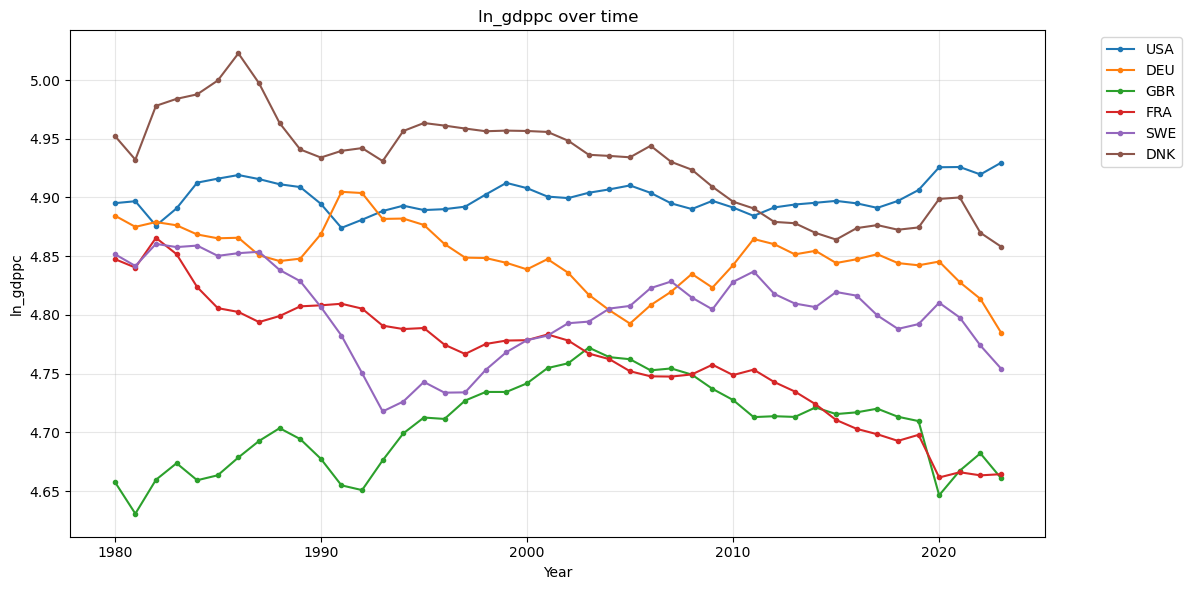

In [10]:
from clean import plot_time_series, plot_correlation_matrix
import matplotlib.pyplot as plt

# Plot GDP over time for selected countries
plot_time_series(
    master,
    'ln_gdppc',
    countries=['USA', 'DEU', 'GBR', 'FRA', 'SWE', 'DNK']
)

In [ ]:
# Correlation heatmap
plot_correlation_matrix(
    master,
    variables=['ln_gdppc', 'sstran', 'deficit', 'debt', 'inflation_cpi']
)

### 📊 Average Social Security Transfers Across All Countries

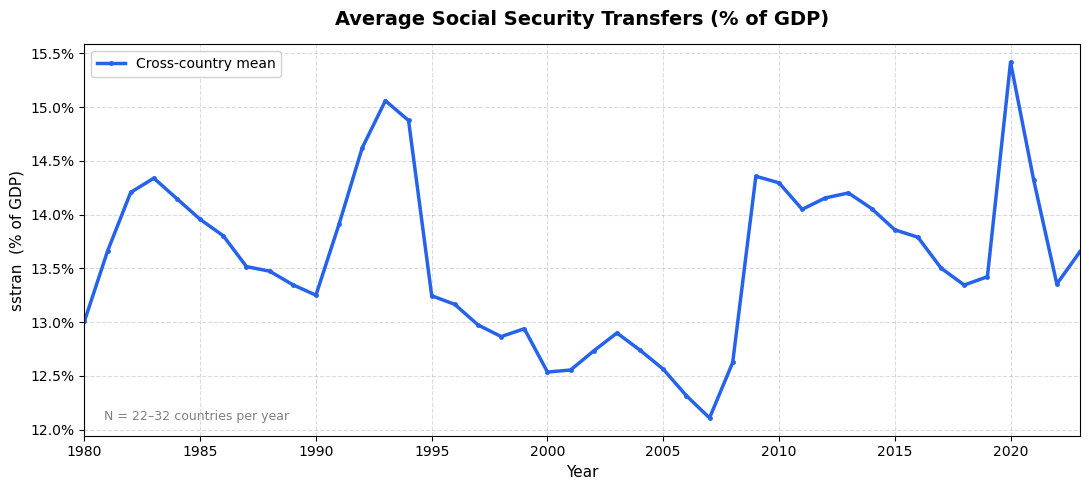


Period average: 13.57% of GDP
Peak year:      2020 (15.42%)
Trough year:    2007 (12.11%)


In [30]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

# ── Compute cross-country mean per year ─────────────────────────────────────────
agg = master.dropna(subset=["sstran"]).copy()

# Ensure numeric types
agg["year"] = pd.to_numeric(agg["year"], errors="coerce")
agg["sstran"] = pd.to_numeric(agg["sstran"], errors="coerce")
agg = agg.dropna(subset=["year", "sstran"])

# Group and calculate mean
agg = (
    agg.groupby("year")["sstran"]
    .agg(mean="mean", n="count")
    .reset_index()
)

# Extract as raw float arrays for matplotlib
x_year = np.array(agg["year"], dtype=float)
y_mean = np.array(agg["mean"], dtype=float)

# ── Plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

# Mean line
ax.plot(
    x_year, y_mean,
    color="#2563EB", linewidth=2.5,
    marker="o", markersize=3.5, markeredgewidth=0,
    label="Cross-country mean"
)

ax.set_title(
    "Average Social Security Transfers (% of GDP)",
    fontsize=14, fontweight="bold", pad=14
)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("sstran  (% of GDP)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.legend(framealpha=0.9, loc="upper left", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.45)
ax.set_xlim(x_year.min(), x_year.max())

# Annotate country count
n_min, n_max = int(agg["n"].min()), int(agg["n"].max())
ax.annotate(
    f"N = {n_min}–{n_max} countries per year",
    xy=(0.02, 0.04), xycoords="axes fraction",
    fontsize=9, color="grey"
)

plt.tight_layout()

# ── Save export ──────────────────────────────────────────────────────
from pathlib import Path

# Create outputs/figures director if it doesn't exist
out_dir = Path(REPO_ROOT) / "outputs" / "figures"
out_dir.mkdir(parents=True, exist_ok=True)

# Save high-res for publications
out_path_png = out_dir / "sstran_average.png"
out_path_pdf = out_dir / "sstran_average.pdf"

fig.savefig(out_path_png, dpi=300, bbox_inches="tight")
fig.savefig(out_path_pdf, bbox_inches="tight")

print(f"\n✅ Saved figure to: {out_path_png}")

plt.show()

# Quick numeric summary
print(f"\nPeriod average: {agg['mean'].mean():.2f}% of GDP")
print(f"Peak year:      {int(agg.loc[agg['mean'].idxmax(), 'year'])} ({agg['mean'].max():.2f}%)")
print(f"Trough year:    {int(agg.loc[agg['mean'].idxmin(), 'year'])} ({agg['mean'].min():.2f}%)")

### 🌍 Average KOF Globalization Indices Across All Countries

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

from pathlib import Path

# ── Compute cross-country mean for KOF indices ───────────────────────
indices = ["KOFGI", "KOFEcGI", "KOFSoGI", "KOFPoGI"]
labels = {
    "KOFGI": "Total Globalization",
    "KOFEcGI": "Economic Globalization",
    "KOFSoGI": "Social Globalization",
    "KOFPoGI": "Political Globalization"
}
colors = {
    "KOFGI": "#E11D48",    # Red
    "KOFEcGI": "#2563EB",  # Blue
    "KOFSoGI": "#10B981",  # Green
    "KOFPoGI": "#F59E0B"   # Orange
}

# Ensure numeric types and drop NaNs
kof_data = master[["year", "iso3"] + indices].copy()
for col in ["year"] + indices:
    kof_data[col] = pd.to_numeric(kof_data[col], errors="coerce")

# Calculate yearly mean
agg_kof = (
    kof_data.dropna(subset=indices, how="all")
    .groupby("year")[indices]
    .mean()
    .reset_index()
)

# Extract x_year as raw float array
x_year = np.array(agg_kof["year"], dtype=float)

# ── Plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

for idx in indices:
    y_values = np.array(agg_kof[idx], dtype=float)
    ax.plot(
        x_year, y_values,
        label=labels[idx], color=colors[idx],
        linewidth=2.5, marker="o", markersize=3, markeredgewidth=0
    )

ax.set_title(
    "Average KOF Globalization Indices (0-100)",
    fontsize=14, fontweight="bold", pad=14
)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Index Value (Higher = More Globalized)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f"))
ax.legend(framealpha=0.9, loc="upper left", fontsize=10)
ax.grid(True, linestyle="--", alpha=0.45)
ax.set_xlim(x_year.min(), x_year.max())
ax.set_ylim(0, 100) # KOF indices are 0-100

plt.tight_layout()

# ── Save export ──────────────────────────────────────────────────────
out_dir = Path(REPO_ROOT) / "outputs" / "figures"
out_dir.mkdir(parents=True, exist_ok=True)

out_path_png = out_dir / "kof_indices_average.png"
out_path_pdf = out_dir / "kof_indices_average.pdf"

fig.savefig(out_path_png, dpi=300, bbox_inches="tight")
fig.savefig(out_path_pdf, bbox_inches="tight")

print(f"\n✅ Saved figure to: {out_path_png}")

plt.show()

# Quick summary
print(f"\nOverall Globalization (KOFGI) trend: {agg_kof['KOFGI'].iloc[0]:.1f} (1980) \u2192 {agg_kof['KOFGI'].iloc[-1]:.1f} ({int(x_year[-1])})")

## 🔧 Part 7: Filter by Country Groups

In [ ]:
from clean import filter_by_region, list_regions

# See available regions
list_regions()

In [ ]:
# Filter to Nordic countries
nordic = filter_by_region(master, 'nordic')
print(f"Nordic countries: {nordic['iso3'].unique()}")
print(f"{len(nordic):,} observations")

## 🎯 Part 8: Robustness Checks

In [ ]:
from clean.robustness import run_robustness_checks, compare_robustness_results
from statsmodels.formula.api import ols

# Run model with automated robustness checks
robust_results = run_robustness_checks(
    master_with_lags,
    'sstran ~ ln_gdppc + deficit + ln_gdppc_lag1',
    ols,
    checks=['drop_outliers', 'winsorize', 'pre_2008', 'post_2008']
)

In [ ]:
# Compare coefficients across specifications
comparison = compare_robustness_results(robust_results, variable='ln_gdppc')

## 📄 Part 9: Publication Table

In [ ]:
from clean import create_publication_table

# Create publication-ready table
pub_table = create_publication_table(
    list(robust_results.values()),
    model_names=['Baseline', 'No Outliers', 'Winsorized', 'Pre-2008', 'Post-2008'],
    output_format='text'
)

print(pub_table)

## 📝 Part 10: Generate Methods Section

In [ ]:
from clean import generate_methods_section

# Auto-generate data section for paper
methods = generate_methods_section(
    master,
    output_path=REPO_ROOT / "paper" / "methods.md"
)

print("Methods section generated! Preview:")
print(methods[:500] + "...")

## 🔄 Part 11: Export to R/Stata

In [ ]:
from clean.export import export_to_r, export_to_stata_script

# Generate R script with pre-configured models
export_to_r(
    master_with_lags,
    REPO_ROOT / 'analysis' / 'analysis.R',
    include_packages=['fixest', 'plm', 'did']
)

# Generate Stata script
export_to_stata_script(
    master_with_lags,
    REPO_ROOT / 'analysis' / 'analysis.do'
)

## ✅ Done!

**You now have:**
- ✅ Processed and merged datasets
- ✅ Quality reports
- ✅ Statistical tests
- ✅ Lags for dynamic models
- ✅ Robustness checks
- ✅ Publication tables
- ✅ Auto-generated methods section
- ✅ R/Stata scripts

**Ready for research!** 🚀